In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"Shape:{df.shape}")
df.head()

Shape:(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True)*100)
#Below results show dataset is imbalanced

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [12]:
#EDA begins here
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
# TotalCharges should be numeric but is stored as text (object)
print(df['TotalCharges'].dtype)

# Checking for blank spaces disguised as values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# checking for missing values again
print(df['TotalCharges'].isnull().sum())  #11 missing values

object
11


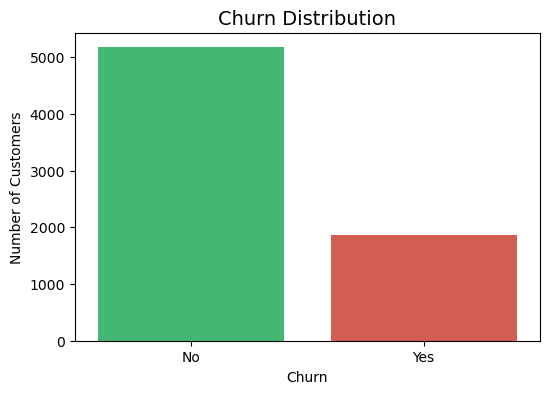

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, hue='Churn', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Churn Distribution', fontsize=14)
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

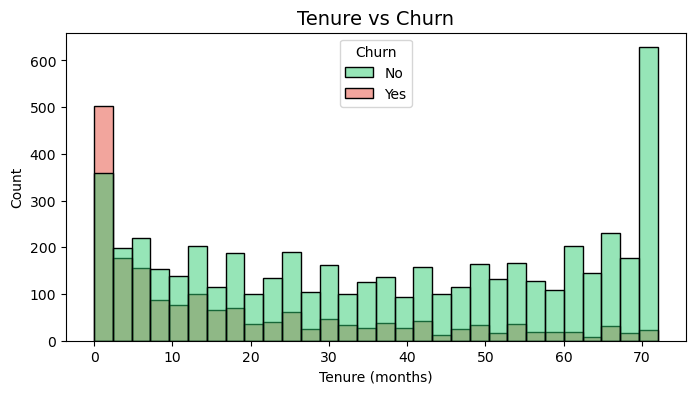

In [17]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette=['#2ecc71', '#e74c3c'])
plt.title('Tenure vs Churn', fontsize=14)
plt.xlabel('Tenure (months)')
plt.show()

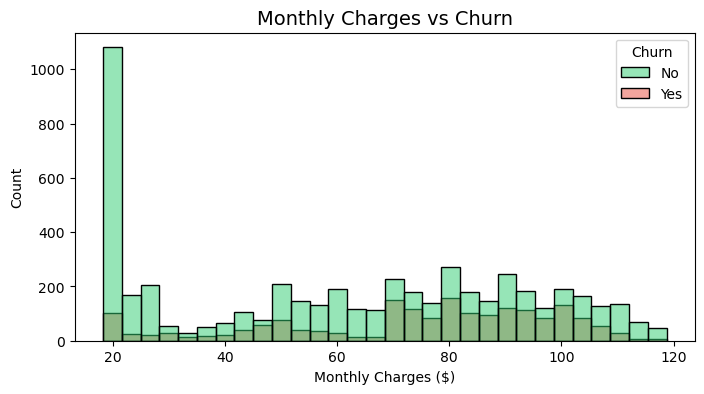

In [18]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, palette=[ '#2ecc71', '#e74c3c'])
plt.title('Monthly Charges vs Churn', fontsize=14)
plt.xlabel('Monthly Charges($)')
plt.show()

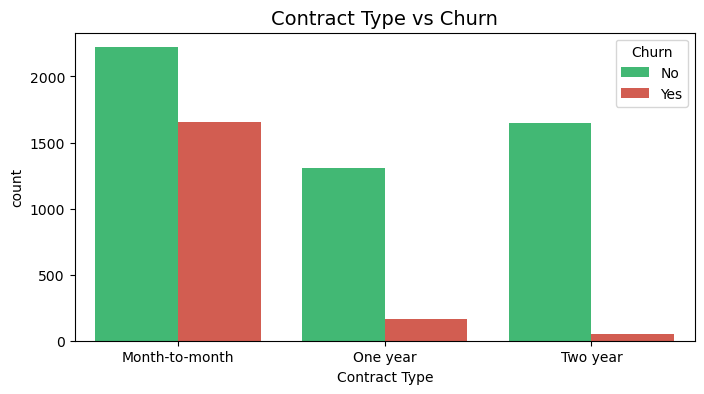

In [19]:
plt.figure(figsize=(8, 4))
sns.countplot(x='Contract', hue='Churn', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Contract Type vs Churn', fontsize=14)
plt.xlabel('Contract Type')
plt.show()

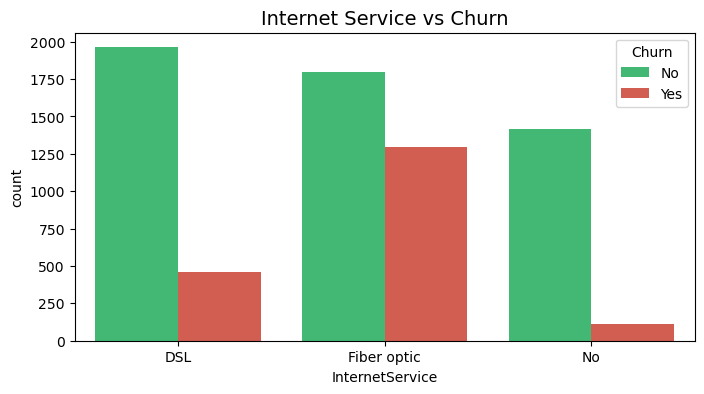

In [20]:
plt.figure(figsize=(8, 4))
sns.countplot(x='InternetService', hue='Churn', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Internet Service vs Churn', fontsize=14)
plt.show()

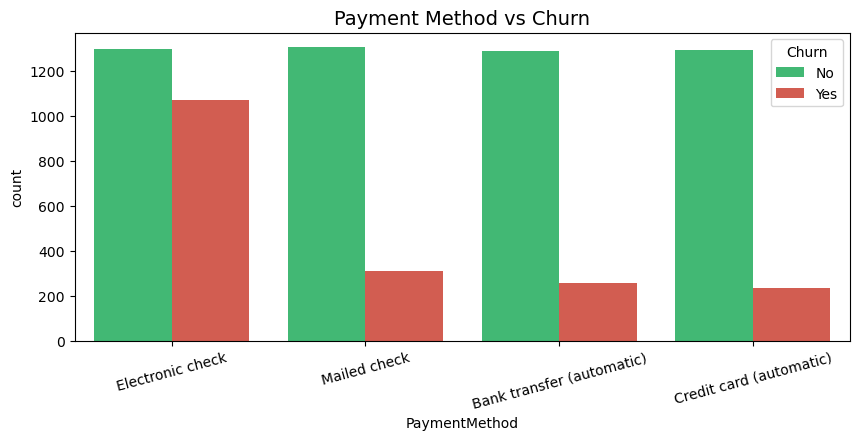

In [21]:
plt.figure(figsize=(10, 4))
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Payment Method vs Churn', fontsize=14)
plt.xticks(rotation=15)
plt.show()

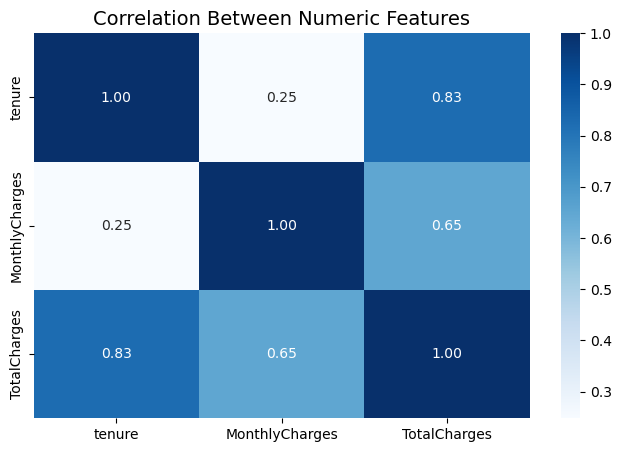

In [23]:
plt.figure(figsize=(8, 5))
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Between Numeric Features', fontsize=14)
plt.show()

In [24]:
# customerID is just a unique identifier-no predictive value
df = df.drop(columns=['customerID'])

print("customerID column dropped!")
print(f"New shape: {df.shape}")  #(7043, 20)

customerID column dropped!
New shape: (7043, 20)


In [25]:
# From EDA found 11 missing values in TotalCharges
# These are new customers with 0 tenure -fill with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("Missing values fixed!")
print(df.isnull().sum().sum())  # 0

Missing values fixed!
0


In [26]:
# Convertion of Churn: Yes → 1, No → 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(df['Churn'].value_counts())


Churn
0    5174
1    1869
Name: count, dtype: int64


In [27]:
# columns are still text (object type)
print(df.select_dtypes(include='object').columns.tolist())



['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [28]:
# These columns only have 2 values: Yes/No or Male/Female
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 
               'PaperlessBilling', 'MultipleLines']

# For gender: Male → 1, Female → 0
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# For Yes/No columns: Yes → 1, No → 0
yes_no_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in yes_no_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

print("Binary columns converted!")

Binary columns converted!


In [29]:
# MultipleLines has 3 values: Yes, No, No phone service
# "No phone service" same as "No"
df['MultipleLines'] = df['MultipleLines'].map({
    'Yes': 1, 
    'No': 0, 
    'No phone service': 0
})

print(df['MultipleLines'].value_counts())

MultipleLines
0    4072
1    2971
Name: count, dtype: int64


In [30]:
# These columns have 3 values: Yes, No, No internet service
internet_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in internet_cols:
    df[col] = df[col].map({
        'Yes': 1, 
        'No': 0, 
        'No internet service': 0
    })

print("Internet service columns converted!")

Internet service columns converted!


In [8]:
# InternetService, Contract, PaymentMethod have 3+ categories
# We use One-Hot Encoding for these

df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], 
                    drop_first=True)

print("One-Hot Encoding done!")
print(f"New shape: {df.shape}")

'''🔑 What is One-Hot Encoding?
Instead of Contract = "Month-to-month", it creates separate columns:

Contract_One year → 0 or 1
Contract_Two year → 0 or 1

drop_first=True drops one category to avoid redundancy.'''

One-Hot Encoding done!
New shape: (7043, 25)


'🔑 What is One-Hot Encoding?\nInstead of Contract = "Month-to-month", it creates separate columns:\n\nContract_One year → 0 or 1\nContract_Two year → 0 or 1\n\ndrop_first=True drops one category to avoid redundancy.'

In [34]:
X = df.drop(columns=['Churn'])  # All columns except Churn
y = df['Churn']                 # Only the Churn column

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (7043, 23)
Target shape: (7043,)


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing, 80% for training
    random_state=42,    # So results are reproducible
    stratify=y          # Maintain same churn ratio in both splits
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (5634, 23)
Testing set: (1409, 23)


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Only scale numeric columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Scaling done!")

Scaling done!


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Build the model
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Train it
lr_model.fit(X_train, y_train)

# Predict on test data
lr_pred = lr_model.predict(X_test)

# Evaluate
print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print()
print(classification_report(y_test, lr_pred, target_names=['No Churn', 'Churn']))

=== Logistic Regression ===
Accuracy: 0.8055

              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



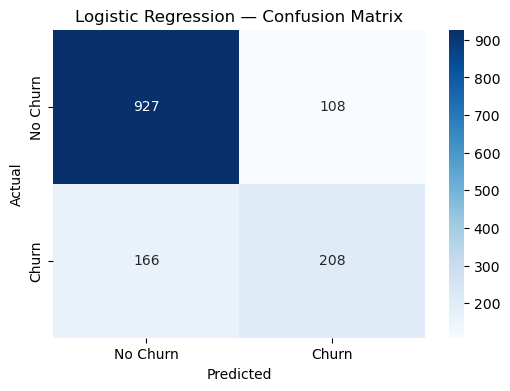

In [40]:
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()




In [42]:
from sklearn.ensemble import RandomForestClassifier

# Build the model
rf_model = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

# Evaluate
print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print()
print(classification_report(y_test, rf_pred, target_names=['No Churn', 'Churn']))


=== Random Forest ===
Accuracy: 0.7899

              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [48]:
!python -m pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 2.1 MB/s eta 0:00:50
   ---------------------------------------- 0.8/101.7 MB 2.0 MB/s eta 0:00:50
   ---------------------------------------- 1.0/101.7 MB 1.6 MB/s eta 0:01:04
    --------------------------------------- 1.3/101.7 MB 1.5 MB/s eta 0:01:08
    --------------------------------------- 1.8/101.7 MB 1.6 MB/s eta 0:01:01
    --------------------------------------- 2.4/101.7 MB 1.8 MB/s eta 0:00:56
   - -------------------------------------- 2.9/101.7 MB 1.9 MB/s eta 0:00:51
   - -------------------------------------- 3.7/101.7 MB 2.1 MB/s eta 0:00:47
   - -------------------------------------- 4.2/101.7 MB 2.2 MB/s eta 0:00:46
   - -------------------------------------- 5.0/101.7 MB 2.3 MB/s eta 0:00:43
   -- ------------------------------------- 5.5/101.7 MB 2.3 MB/s eta 0

In [49]:

# to install in  terminal: pip install xgboost

from xgboost import XGBClassifier

# Build the model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',   # Suppresses a warning
    use_label_encoder=False  # Suppresses a warning
)

# Train 
xgb_model.fit(X_train, y_train)

# Predict
xgb_pred = xgb_model.predict(X_test)

# Evaluate
print("=== XGBoost ===")
print(f"Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print()
print(classification_report(y_test, xgb_pred, target_names=['No Churn', 'Churn']))




=== XGBoost ===
Accuracy: 0.7928

              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.63      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



C:\Users\Asus\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [11:12:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [50]:
from sklearn.metrics import f1_score, recall_score, precision_score

models = {
    'Logistic Regression': lr_pred,
    'Random Forest': rf_pred,
    'XGBoost': xgb_pred
}

print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 65)

for name, pred in models.items():
    acc = accuracy_score(y_test, pred)
    pre = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    print(f"{name:<25} {acc:>10.4f} {pre:>10.4f} {rec:>10.4f} {f1:>10.4f}")


Model                       Accuracy  Precision     Recall         F1
-----------------------------------------------------------------
Logistic Regression           0.8055     0.6582     0.5561     0.6029
Random Forest                 0.7899     0.6327     0.4973     0.5569
XGBoost                       0.7928     0.6289     0.5348     0.5780


In [51]:
#Improved LR
lr_balanced = LogisticRegression(
    random_state=42, 
    max_iter=1000,
    class_weight='balanced'   # ← This is the key change
)

lr_balanced.fit(X_train, y_train)
lr_balanced_pred = lr_balanced.predict(X_test)

print("=== Logistic Regression (Balanced) ===")
print(f"Accuracy: {accuracy_score(y_test, lr_balanced_pred):.4f}")
print()
print(classification_report(y_test, lr_balanced_pred, target_names=['No Churn', 'Churn']))


=== Logistic Regression (Balanced) ===
Accuracy: 0.7402

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [53]:
#Improved XGBOost
# Calculating imbalance ratio
neg = (y_train == 0).sum()   # No churn count
pos = (y_train == 1).sum()   # Churn count
ratio = neg / pos

print(f"Imbalance ratio: {ratio:.2f}")  # ~2.76

xgb_balanced = XGBClassifier(
    n_estimators=200,          # More trees
    learning_rate=0.05,        # Slower learning = more careful
    max_depth=4,               # Shallower trees = less overfitting
    scale_pos_weight=ratio,    # ← Tells XGBoost about imbalance
    random_state=42,
    eval_metric='logloss'
)

xgb_balanced.fit(X_train, y_train)
xgb_balanced_pred = xgb_balanced.predict(X_test)

print("=== XGBoost (Balanced) ===")
print(f"Accuracy: {accuracy_score(y_test, xgb_balanced_pred):.4f}")
print()
print(classification_report(y_test, xgb_balanced_pred, target_names=['No Churn', 'Churn']))


Imbalance ratio: 2.77
=== XGBoost (Balanced) ===
Accuracy: 0.7480

              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1035
       Churn       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.81      0.75      0.76      1409



In [54]:
#Model Comparision
all_models = {
    'LR (original)': lr_pred,
    'LR (balanced)': lr_balanced_pred,
    'Random Forest': rf_pred,
    'XGBoost (original)': xgb_pred,
    'XGBoost (balanced)': xgb_balanced_pred
}

print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 65)

for name, pred in all_models.items():
    acc = accuracy_score(y_test, pred)
    pre = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    print(f"{name:<25} {acc:>10.4f} {pre:>10.4f} {rec:>10.4f} {f1:>10.4f}")


Model                       Accuracy  Precision     Recall         F1
-----------------------------------------------------------------
LR (original)                 0.8055     0.6582     0.5561     0.6029
LR (balanced)                 0.7402     0.5069     0.7861     0.6164
Random Forest                 0.7899     0.6327     0.4973     0.5569
XGBoost (original)            0.7928     0.6289     0.5348     0.5780
XGBoost (balanced)            0.7480     0.5164     0.7995     0.6275


In [55]:
#ROC-AUC Score
from sklearn.metrics import roc_auc_score, roc_curve

# Get probability scores (not just 0/1 predictions)
xgb_proba = xgb_balanced.predict_proba(X_test)[:, 1]
lr_proba = lr_balanced.predict_proba(X_test)[:, 1]

print(f"XGBoost ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}")
print(f"Logistic Regression ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}")

XGBoost ROC-AUC: 0.8417
Logistic Regression ROC-AUC: 0.8419


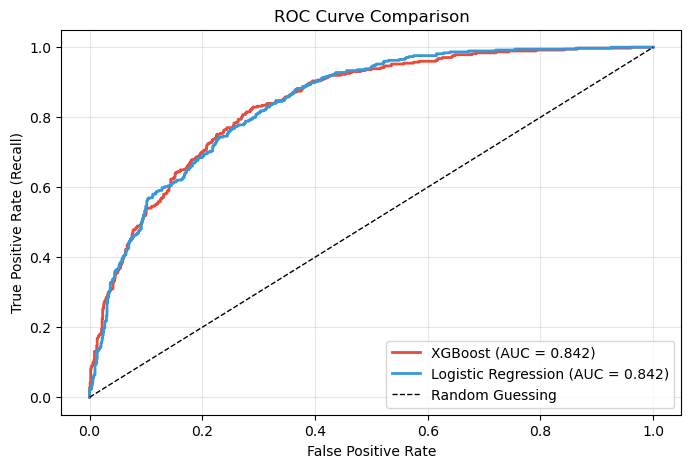

In [56]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)

plt.figure(figsize=(8, 5))
plt.plot(fpr_xgb, tpr_xgb, color='#e74c3c', lw=2, 
         label=f'XGBoost (AUC = {roc_auc_score(y_test, xgb_proba):.3f})')
plt.plot(fpr_lr, tpr_lr, color='#3498db', lw=2,
         label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

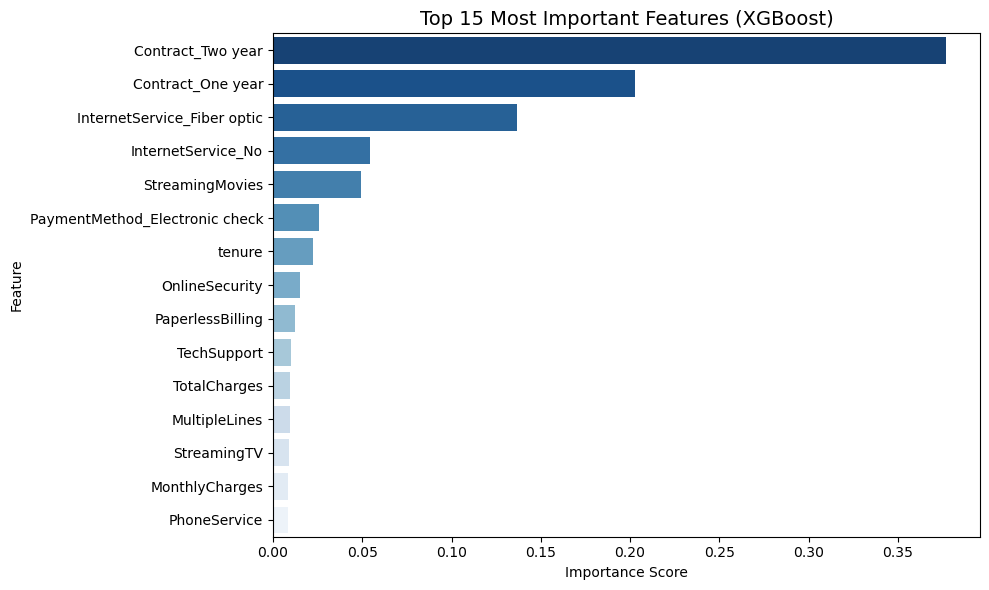

                           Feature  Importance
19               Contract_Two year    0.377057
18               Contract_One year    0.202926
16     InternetService_Fiber optic    0.136397
17              InternetService_No    0.054347
12                 StreamingMovies    0.049091
21  PaymentMethod_Electronic check    0.025900
4                           tenure    0.022296
7                   OnlineSecurity    0.015059
13                PaperlessBilling    0.012197
10                     TechSupport    0.010122
15                    TotalCharges    0.009515
6                    MultipleLines    0.009389
11                     StreamingTV    0.009272
14                  MonthlyCharges    0.008468
5                     PhoneService    0.008445


In [57]:
#Feature Importance
#  feature importances
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_balanced.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, 
            hue='Feature', palette='Blues_r', legend=False)
plt.title('Top 15 Most Important Features (XGBoost)', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(importance_df)

In [58]:
## Instead of 0.5 threshold, used 0.4
xgb_proba = xgb_balanced.predict_proba(X_test)[:, 1]
xgb_threshold_pred = (xgb_proba >= 0.4).astype(int)

print("=== XGBoost with 0.4 Threshold ===")
print(classification_report(y_test, xgb_threshold_pred, 
      target_names=['No Churn', 'Churn']))
# Instead of 0.5 threshold, use 0.4
xgb_proba = xgb_balanced.predict_proba(X_test)[:, 1]
xgb_threshold_pred = (xgb_proba >= 0.4).astype(int)

print("=== XGBoost with 0.4 Threshold ===")
print(classification_report(y_test, xgb_threshold_pred, 
      target_names=['No Churn', 'Churn']))

=== XGBoost with 0.4 Threshold ===
              precision    recall  f1-score   support

    No Churn       0.92      0.67      0.78      1035
       Churn       0.48      0.84      0.61       374

    accuracy                           0.72      1409
   macro avg       0.70      0.76      0.69      1409
weighted avg       0.80      0.72      0.73      1409

=== XGBoost with 0.4 Threshold ===
              precision    recall  f1-score   support

    No Churn       0.92      0.67      0.78      1035
       Churn       0.48      0.84      0.61       374

    accuracy                           0.72      1409
   macro avg       0.70      0.76      0.69      1409
weighted avg       0.80      0.72      0.73      1409



In [59]:
#import joblib
import os

# Create a models folder
os.makedirs('models', exist_ok=True)

# Save the model
joblib.dump(xgb_balanced, 'models/churn_model.pkl')

# Save the scaler too — you'll need it to preprocess new data
joblib.dump(scaler, 'models/scaler.pkl')

print("Model saved successfully!")

import joblib
import os

# Create a models folder
os.makedirs('models', exist_ok=True)

# Save the model
joblib.dump(xgb_balanced, 'models/churn_model.pkl')

# Save the scaler too — you'll need it to preprocess new data
joblib.dump(scaler, 'models/scaler.pkl')

print("Model saved successfully!")

Model saved successfully!


In [62]:
# Test : Loads Correctly
# Load it back
loaded_model = joblib.load('models/churn_model.pkl')
loaded_scaler = joblib.load('models/scaler.pkl')

# test prediction
test_pred = loaded_model.predict(X_test[:5])
print("Test predictions:", test_pred)
print("Actual values:   ", y_test[:5].values)
print("Model loaded and working correctly!")

Test predictions: [0 1 0 1 0]
Actual values:    [0 0 0 0 0]
Model loaded and working correctly!


In [63]:
#Predict on a Brand New Customer
import numpy as np

# Created a sample customer
# This must match EXACTLY the columns X_train has after preprocessing
sample_customer = pd.DataFrame([{
    'gender': 1,                          # Male
    'SeniorCitizen': 0,                   # Not senior
    'Partner': 1,                         # Has partner
    'Dependents': 0,                      # No dependents
    'tenure': 2,                          # Only 2 months — HIGH RISK
    'PhoneService': 1,                    # Has phone
    'MultipleLines': 0,                   # No multiple lines
    'OnlineSecurity': 0,                  # No online security
    'OnlineBackup': 0,                    # No backup
    'DeviceProtection': 0,               # No protection
    'TechSupport': 0,                     # No tech support
    'StreamingTV': 1,                     # Streams TV
    'StreamingMovies': 1,                 # Streams movies
    'PaperlessBilling': 1,               # Paperless billing
    'MonthlyCharges': 85.0,              # High charges
    'TotalCharges': 170.0,               # Low total (new customer)
    'InternetService_Fiber optic': 1,    # Fiber optic
    'InternetService_No': 0,
    'Contract_One year': 0,
    'Contract_Two year': 0,              # Month-to-month (highest risk)
    'PaymentMethod_Credit card (automatic)': 0,
    'PaymentMethod_Electronic check': 1, # Electronic check
    'PaymentMethod_Mailed check': 0
}])

# Scale numeric columns
sample_customer[num_cols] = loaded_scaler.transform(sample_customer[num_cols])

# Predict
prediction = loaded_model.predict(sample_customer)[0]
probability = loaded_model.predict_proba(sample_customer)[0][1]

print(f"Churn Prediction : {'YES - Will Churn ⚠️' if prediction == 1 else 'NO - Will Stay ✅'}")
print(f"Churn Probability: {probability:.1%}")


Churn Prediction : YES - Will Churn ⚠️
Churn Probability: 87.1%


In [68]:
pip freeze requirements.txt

affine==2.4.0
aiobotocore @ file:///C:/b/abs_431uzunk2v/croot/aiobotocore_1738237882529/work
aiohappyeyeballs @ file:///C:/b/abs_e9fm5mk6ak/croot/aiohappyeyeballs_1734469429350/work
aiohttp @ file:///C:/b/abs_d4_gdjffav/croot/aiohttp_1734687146788/work
aioitertools @ file:///tmp/build/80754af9/aioitertools_1607109665762/work
aiosignal @ file:///tmp/build/80754af9/aiosignal_1637843061372/work
alabaster @ file:///C:/Users/dev-admin/perseverance-python-buildout/croot/alabaster_1729041938345/work
altair @ file:///C:/b/abs_0b1avjyzoc/croot/altair_1743016738596/work
anaconda-anon-usage @ file:///C:/b/abs_1az9wuczyu/croot/anaconda-anon-usage_1749054795139/work
anaconda-auth @ file:///C:/b/abs_66s84uss7v/croot/anaconda-cloud-auth-split_1747863792543/work
anaconda-catalogs @ file:///C:/b/abs_ac59ma63va/croot/anaconda-catalogs_1747774731997/work
anaconda-cli-base @ file:///C:/b/abs_e4_l2p3q_7/croot/anaconda-cli-base_1741369468349/work
anaconda-client @ file:///C:/b/abs_0aa49y56xo/croot/anaconda-

In [10]:
!git init

Initialized empty Git repository in C:/Users/Asus/ProjectsPP/Churn Project/.git/


In [11]:
%%writefile .gitignore
__pycache__/
*.pyc
*.pkl
.env
.ipynb_checkpoints/

Writing .gitignore


In [12]:
!git add .


In [13]:
!git commit -m "Initial commit"

[main (root-commit) 77b4fff] Initial commit
 5 files changed, 9450 insertions(+)
 create mode 100644 .gitignore
 create mode 100644 Untitled.ipynb
 create mode 100644 WA_Fn-UseC_-Telco-Customer-Churn.csv
 create mode 100644 requirements.txt
 create mode 100644 untitled.txt


In [17]:
!git remote add origin https://github.com/rbhatDhan/Churn_Prediction.git

error: remote origin already exists.


In [18]:
!git branch -M main
!git push -u origin main

branch 'main' set up to track 'origin/main'.


To https://github.com/rbhatDhan/Churn_Prediction.git
 * [new branch]      main -> main


In [19]:
!git remote -v

origin	https://github.com/rbhatDhan/Churn_Prediction.git (fetch)
origin	https://github.com/rbhatDhan/Churn_Prediction.git (push)
